In [2]:
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [10]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [11]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [13]:
X_pima = pima_df[pima_cols[:-1]]

In [16]:
y_pima = pima_df['Outcome']

In [17]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [22]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [24]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


In [37]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
from sklearn.metrics import accuracy_score, classification_report

In [41]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [43]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [45]:
clf_preds = tree_clf.predict(X_test_c)

In [47]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [49]:
print("--- Classification Report ---")

--- Classification Report ---


In [51]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [62]:
import matplotlib.pyplot as plt

In [63]:
from sklearn.tree import plot_tree

In [64]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

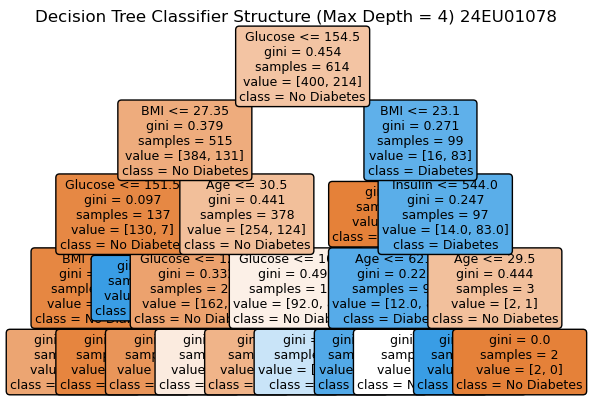

In [70]:
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4) 24EU01078")
plt.show()

In [89]:
from sklearn.tree import DecisionTreeRegressor

In [91]:
from sklearn.preprocessing import StandardScaler

In [93]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [95]:
boston_df = pd.read_csv(boston_url)

In [97]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [99]:
X_boston = boston_df[boston_features]

In [101]:
y_boston = boston_df['medv']

In [103]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [105]:
scaler_r = StandardScaler()

In [107]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [109]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [111]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [113]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [115]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [127]:
from sklearn.metrics import mean_squared_error, r2_score

In [129]:
import numpy as np

In [131]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [133]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [135]:
rmse_val = np.sqrt(mse_val)

In [137]:
r2_val = r2_score(y_test_r, reg_preds)

In [139]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

Mean Squared Error (MSE): 8.5539
Root Mean Squared Error (RMSE): 2.9247 ($1000s)
R2 Coefficient of Determination: 0.8834



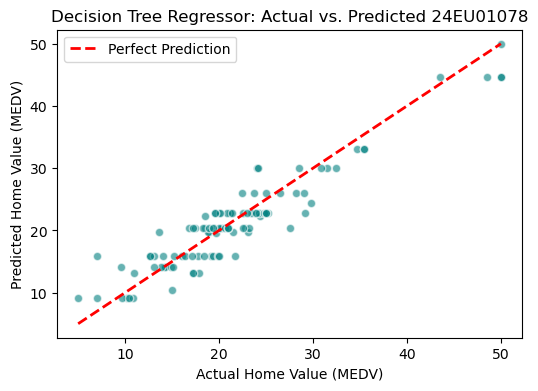

In [141]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted 24EU01078")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

In [146]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})
X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [148]:
print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [151]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)
bagging_preds = bagging_model.predict(X_test_s)
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [154]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_s, y_train_s)
rf_preds = rf_model.predict(X_test_s)
rf_accuracy = accuracy_score(y_test_s, rf_preds)
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


In [157]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_model.fit(X_train_s, y_train_s)
voting_preds = voting_model.predict(X_test_s)
voting_accuracy = accuracy_score(y_test_s, voting_preds)
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


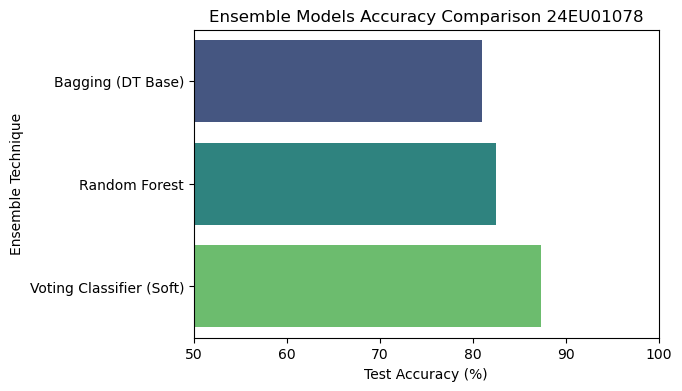

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison 24EU01078")
plt.show()

In [163]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train_s, y_train_s)
ada_preds = adaboost_model.predict(X_test_s)
ada_accuracy = accuracy_score(y_test_s, ada_preds)
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


In [166]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_s, y_train_s)
gb_preds = gb_model.predict(X_test_s)
gb_accuracy = accuracy_score(y_test_s, gb_preds)
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


In [169]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train_s, y_train_s)
best_gb = grid_gb.best_estimator_
tuned_gb_preds = best_gb.predict(X_test_s)
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Tuned Gradient Boosting Test Accuracy: 74.60%


In [171]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)
print("--- Master Performance Table: Tasks 2 & 3 ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 ---
        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175
